In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
from football_analytics.analyses.passing.features import passing_feature_columns
import football_analytics.dqa as dqa
from football_analytics.dqa import dqa_plots
from football_analytics.analyses.passing import passing_story_plots as story

In [4]:
df_2018 = pd.read_parquet("../../../artifacts/features/player_level_wc2018.parquet")
df_2022 = pd.read_parquet("../../../artifacts/features/player_level_wc2022.parquet")

df_2018["dataset"] = "WC2018"
df_2022["dataset"] = "WC2022"

df = pd.concat([df_2018, df_2022], ignore_index=True)

In [5]:
df.head()

,player_key,player,player_position,mean_x_loc,mean_y_loc,def_third_pct,mid_third_pct,att_third_pct,left_channel_pct,mid_channel_pct,...,carry_angle_mean_left_channel,carry_angle_var_left_channel,carry_angle_mean_centre_channel,carry_angle_var_centre_channel,carry_angle_mean_right_channel,carry_angle_var_right_channel,carry_direction_entropy,max_carry_length,carry_burst_index,dataset
0,2941.0,Ismaïla Sarr,Right Wing,70.104839,70.204301,0.153226,0.424731,0.422043,0.002688,0.053763,...,0.000000,0.000000,45.000000,0.292893,-23.252770,0.481536,1.753965,73.348483,0.673399,WC2018
1,2948.0,Nabil Fekir,Center Attacking Midfield,77.225108,53.095238,0.090909,0.402597,0.506494,0.203463,0.207792,...,11.931324,0.487876,39.241641,0.596515,-14.633920,0.771257,1.857849,34.000000,0.312326,WC2018
2,2954.0,Youri Tielemans,Left Center Midfield,60.751073,52.412017,0.175966,0.600858,0.223176,0.090129,0.343348,...,141.436146,0.665877,33.976505,0.510709,-0.382901,0.716938,1.926551,31.016125,0.378164,WC2018
3,2974.0,Saîf-Eddine Khaoui,Left Center Midfield,66.689873,48.886076,0.177215,0.449367,0.373418,0.145570,0.367089,...,-138.522412,0.675923,44.540200,0.518174,-81.907772,0.867797,1.959901,19.798990,0.234385,WC2018
4,2995.0,Ángel Fabián Di María Hernández,Left Wing,82.781768,18.983425,0.093923,0.240331,0.665746,0.817680,0.104972,...,51.765438,0.691145,-89.937304,0.620111,-48.744092,0.305555,1.985895,36.496575,0.462653,WC2018


In [6]:
passing_cols = passing_feature_columns()

In [7]:
passing_df = df[["player_key", "player_position", "player"] + passing_cols]
passing_df.shape

(1285, 127)

In [8]:
report = dqa.feature_quality_report(passing_df, group_col = "player", impossible_rules = [("pass_completed", "pass_attempted"), ("forward_passes", "passes")],)

### Missingness hotspots (null %)

*Features with the highest proportion of missing values. Highlights broken joins and dropped player segments.*

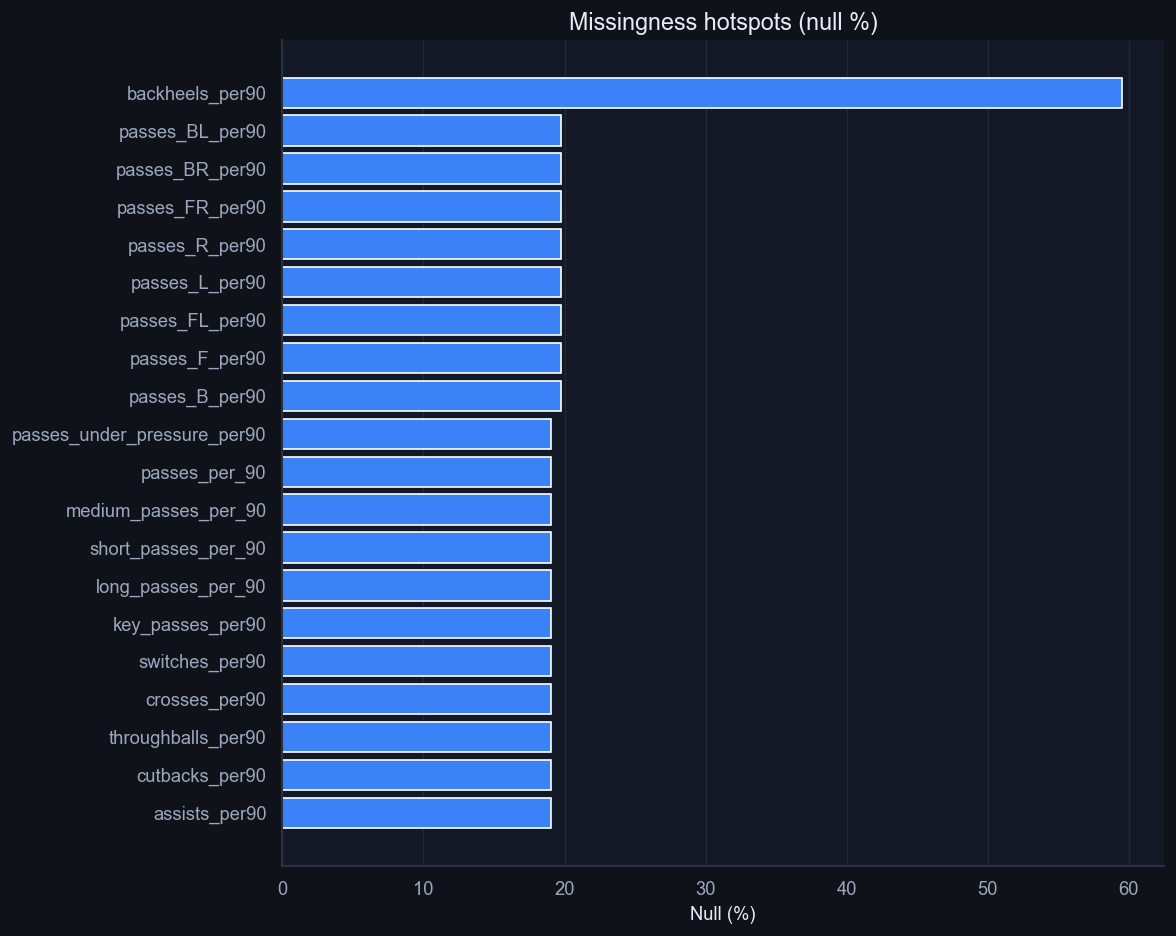

### Outlier pressure (IQR, % rows flagged)

*Fraction of rows flagged as distribution outliers per feature. Catches broken scaling and unstable rate features.*

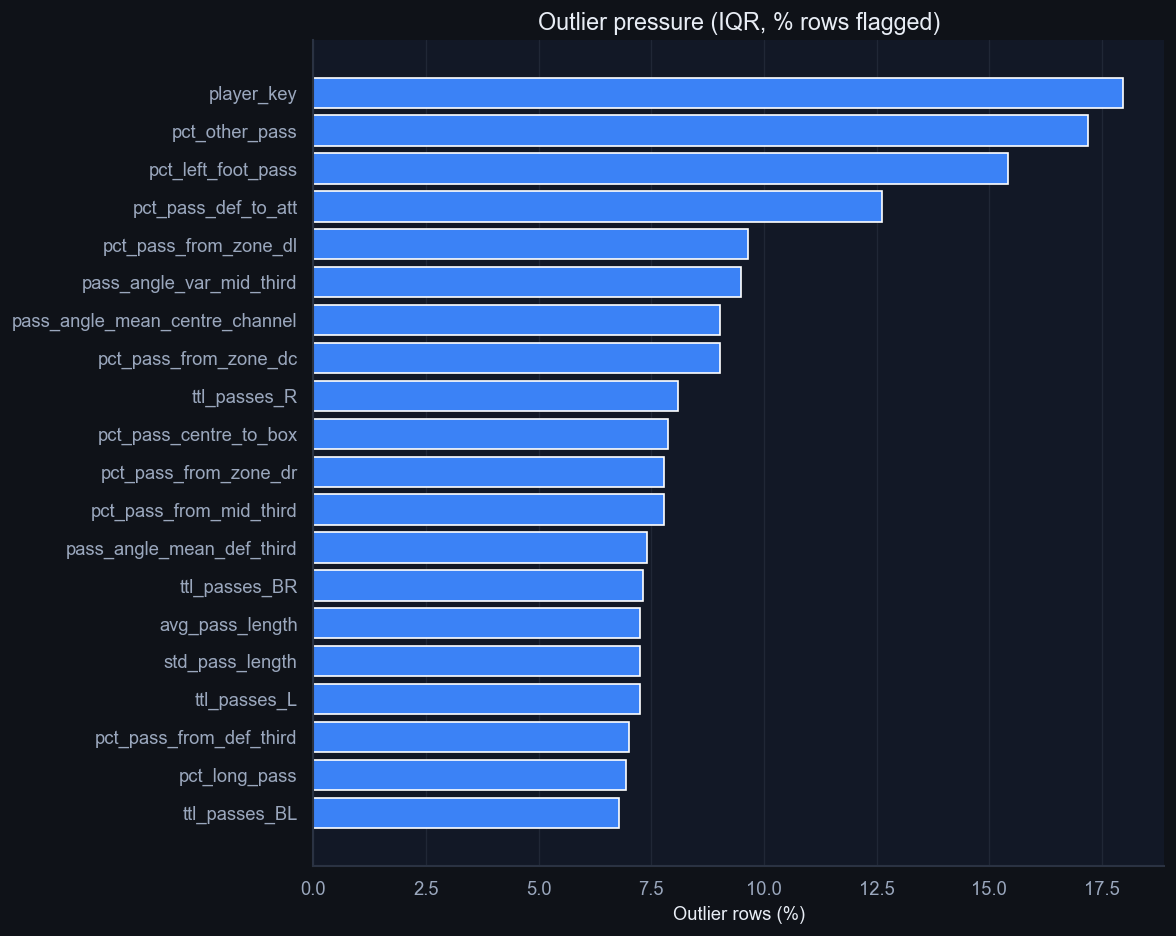

### Low entropy features

*Features with collapsed or near-constant distributions. Detects broken bucketing and low information content.*

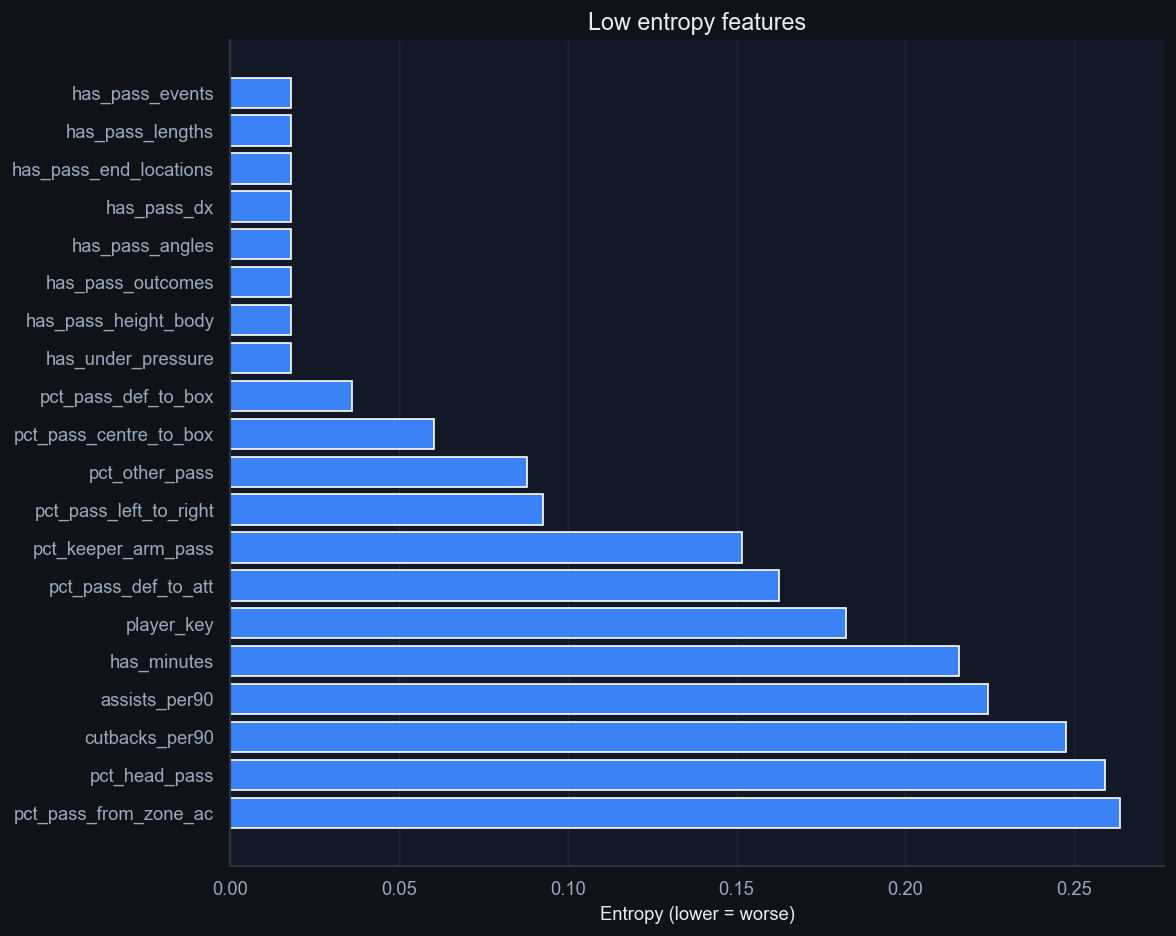

### Correlation cluster (subset heatmap)

*Groups of highly correlated features. Highlights duplicate or redundant joins.*

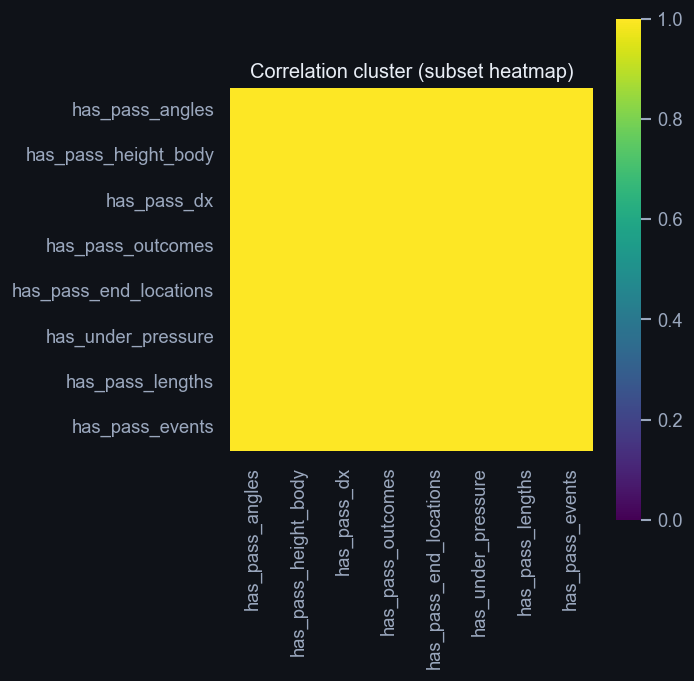

### Feature position signal

*Features that best separate player positions. Identifies semantically meaningful signals.*

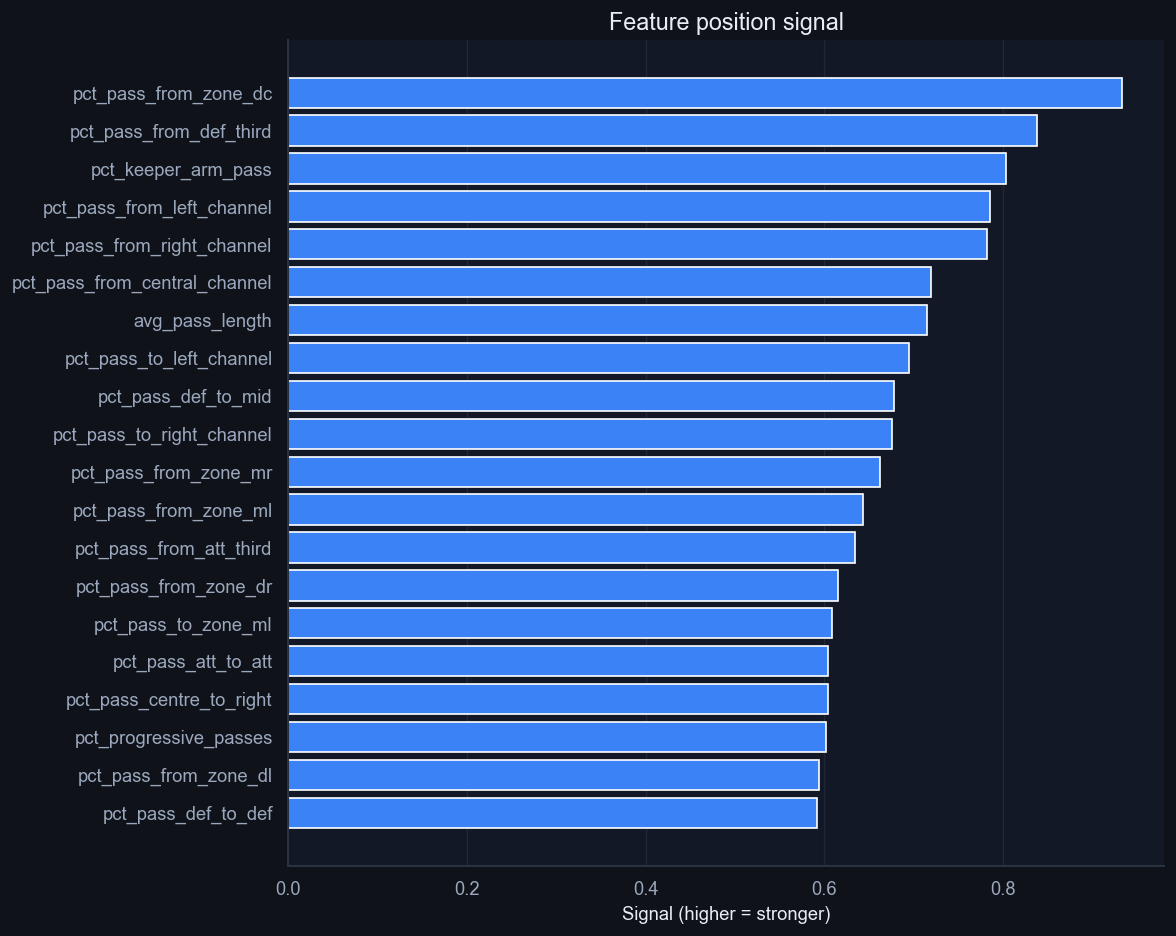

### Position separability

*How well player positions are separated in feature space. Detects semantic collapse.*

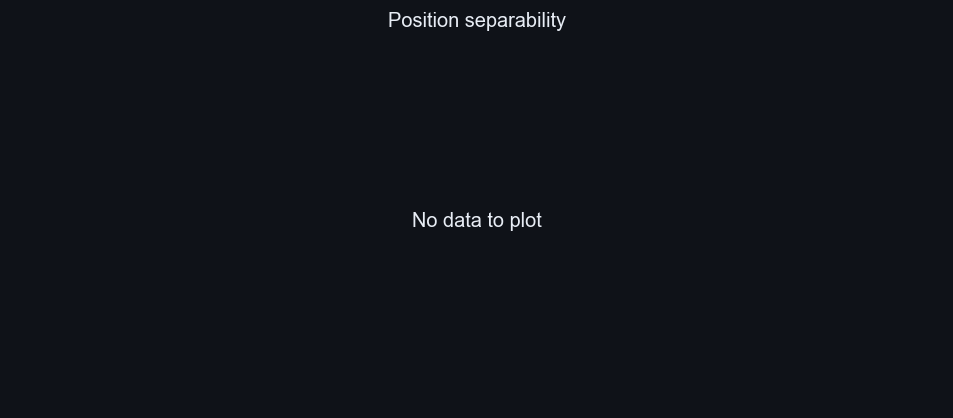

### Within-position variance

*Inconsistency of features within the same position group. Detects unstable role definitions.*

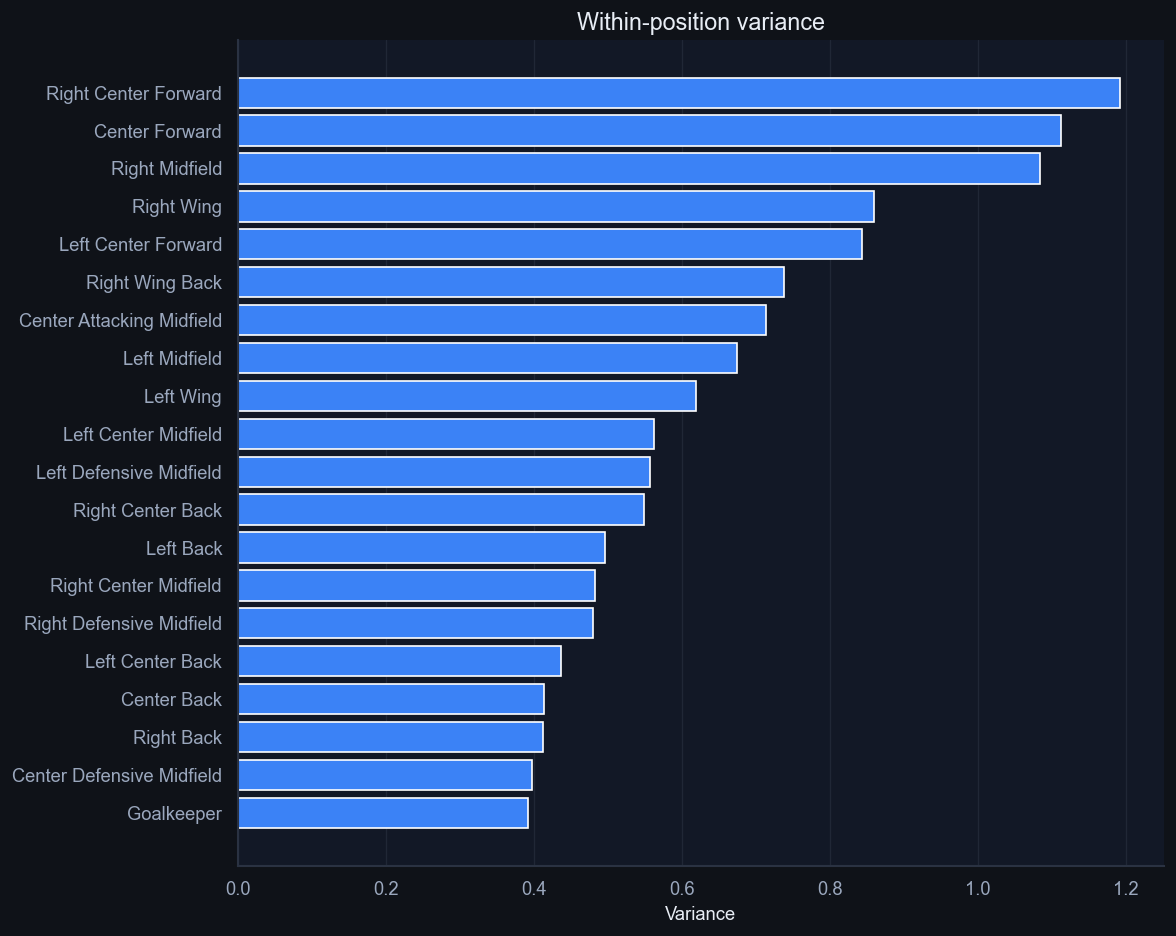

In [9]:
from IPython.display import display, Markdown

plots = dqa_plots.render_dashboard(passing_df, report)

for key, item in plots.items():
    display(Markdown(f"### {item['title']}"))
    if item["description"]:
        display(Markdown(f"*{item['description']}*"))
    display(item["fig"])

### Position separability

*Single-number summary of how well positions form clusters in feature space (silhouette score, -1..1). Higher = more separable roles.*

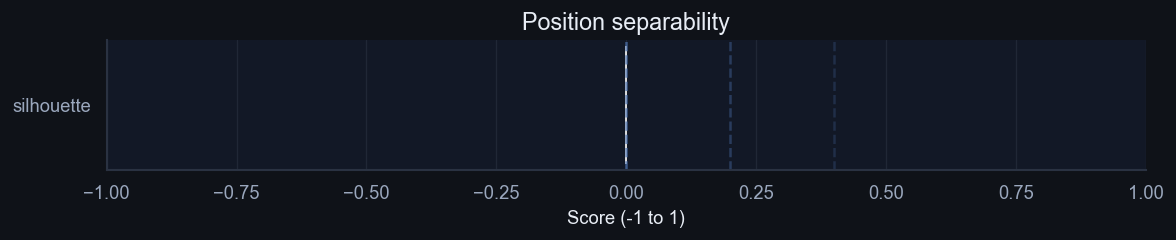

### Position centroid similarity

*Similarity between position archetypes (centroids) in your feature space. High similarity suggests overlapping roles (e.g., WB vs Winger).*

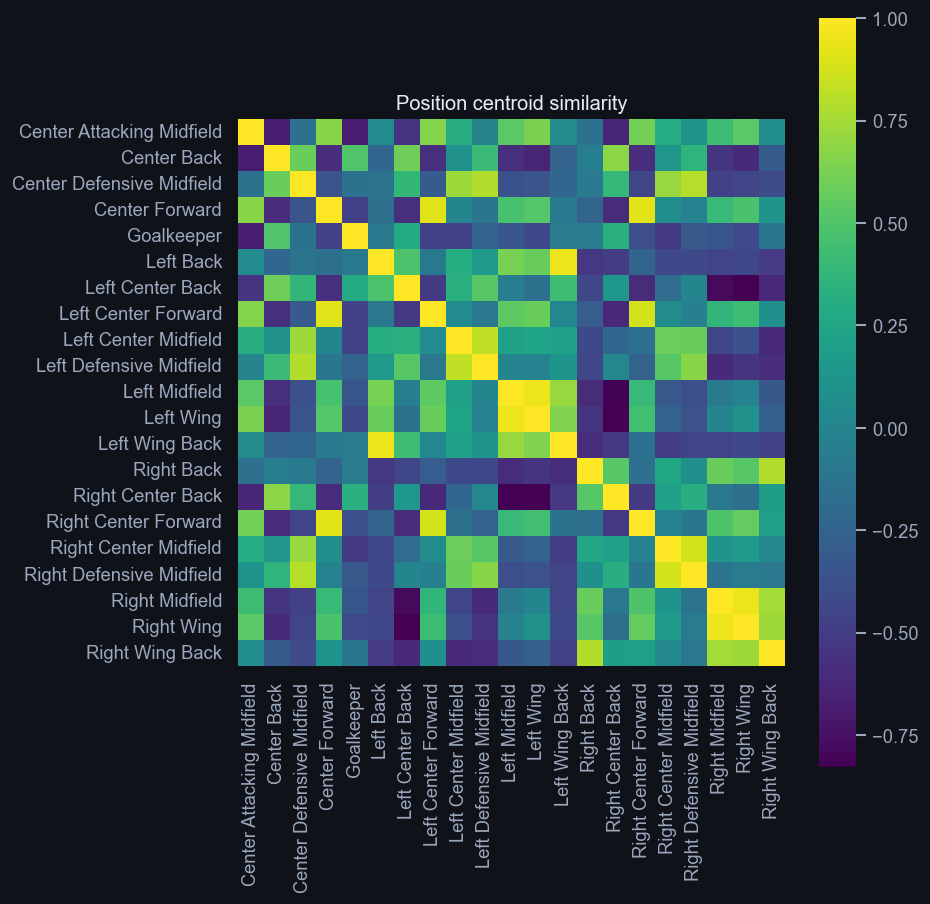

### Feature position signal

*Which features most strongly differentiate positions. Use this to narrate what defines fullbacks vs midfielders vs wingers in your model.*

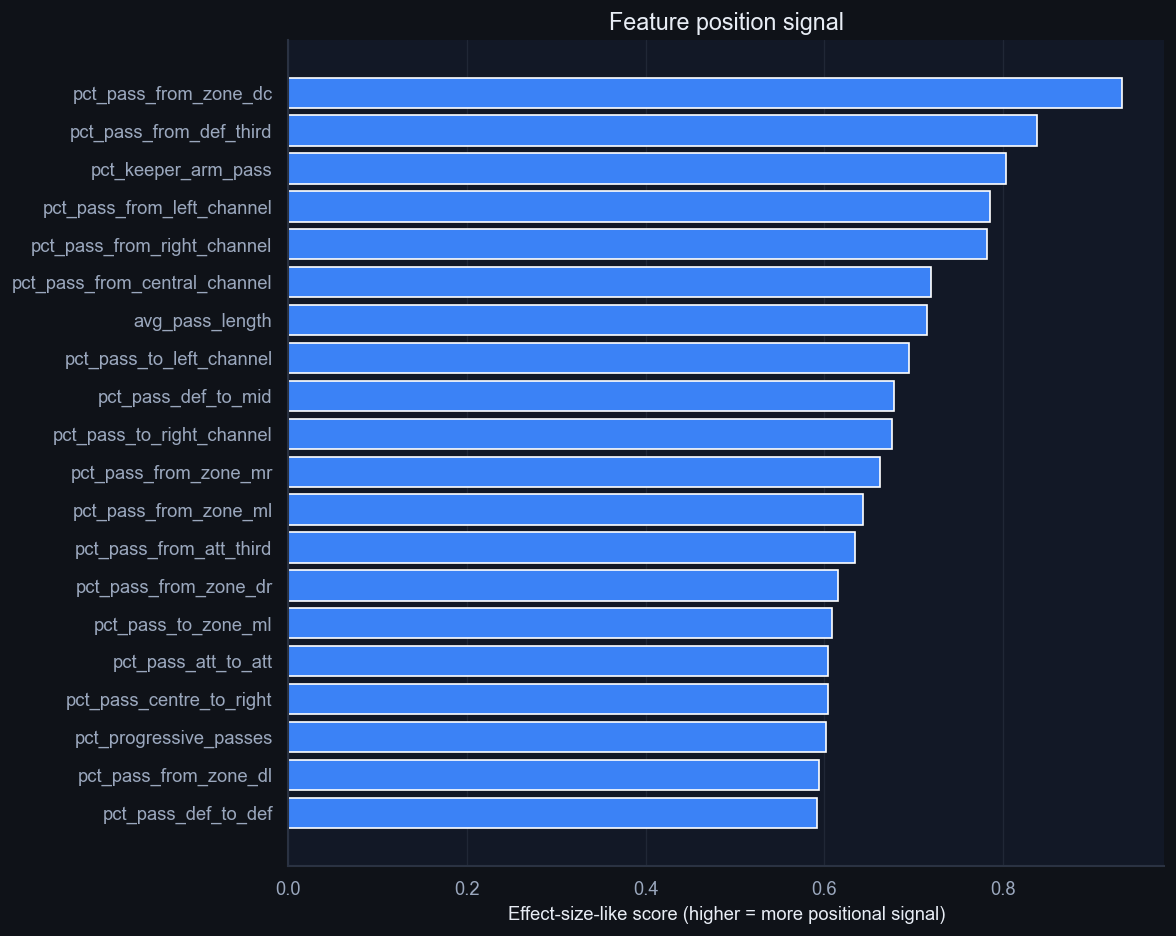

### Within-position variance

*How internally consistent each position is. Higher variance suggests mixed role definitions or tactical freedom within that position group.*

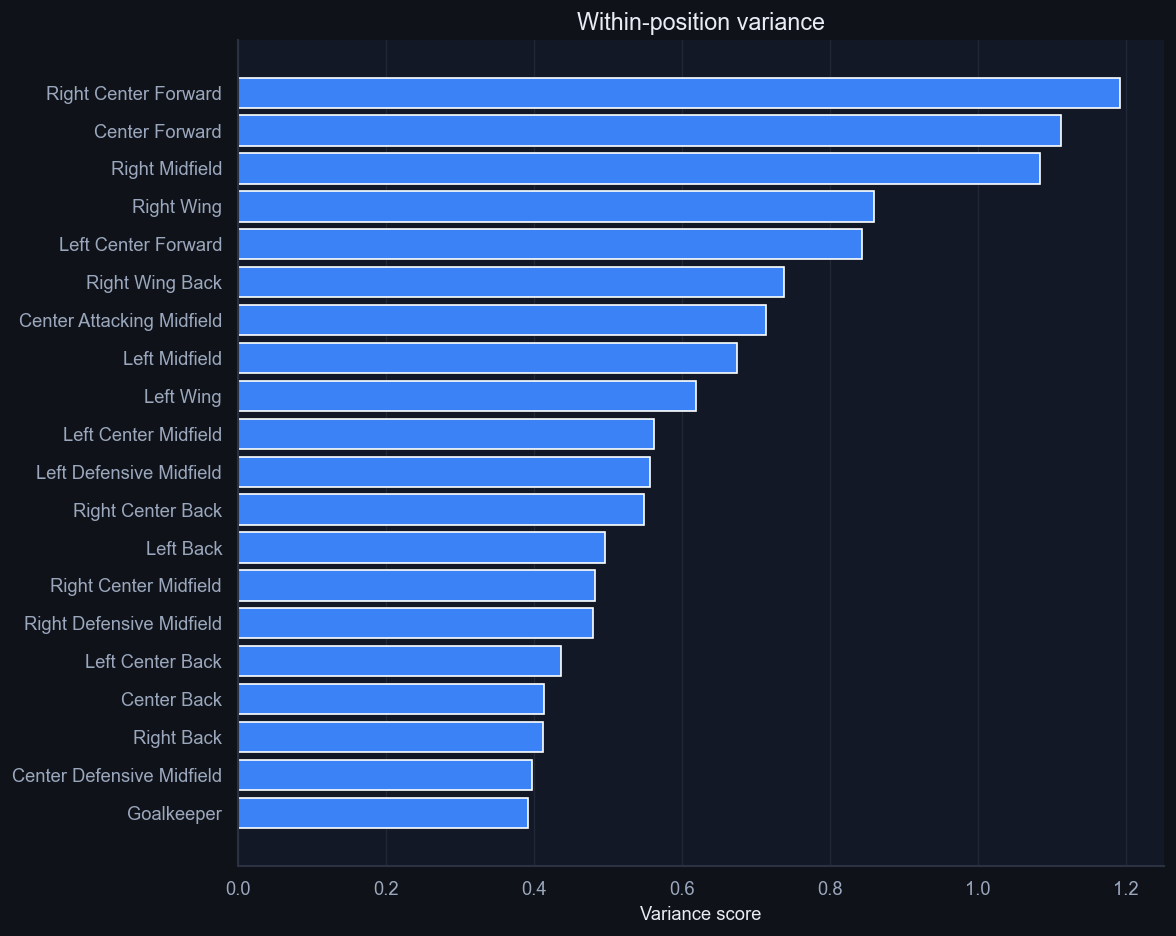

In [10]:
story_plots = story.render_story_dashboard(passing_df, report)
for key, item in story_plots.items():
    display(Markdown(f"### {item['title']}"))
    if item["description"]:
        display(Markdown(f"*{item['description']}*"))
    display(item["fig"])